# BirdCLEF Visualization Notebook

This notebook explores bird audio through both **save-safe static views** and an **interactive synchronized runtime demo**.

It is designed to help readers understand bird sounds across:
- time-domain waveforms
- frequency-domain spectrograms
- direct audio playback

The notebook is organized in two ways:
1. **Save-safe visualization** for stable notebook rendering
2. **Runtime-only synchronized visualization** for interactive exploration

## Interactive Audio-Spectrogram Demo

> ⚠️ Note: The interactive version (with synchronized cursor) may not render correctly after saving.  
> To view it properly, please copy the code and run it in your own environment.

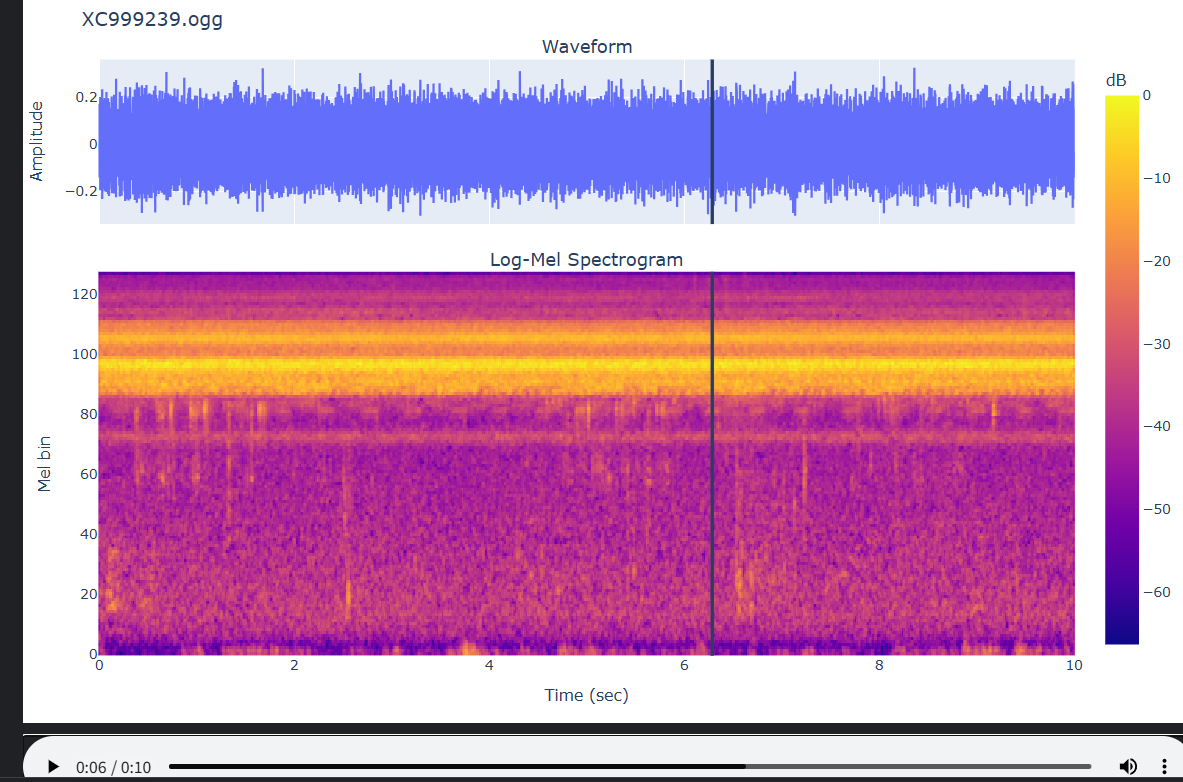

In [ ]:
import os
import io
import uuid
import base64
import wave
import glob
import numpy as np
import librosa
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

TRAIN_DIR = "/kaggle/input/competitions/birdclef-2026/train_audio"
MAX_CLASSES = 10
MAX_FILES_PER_CLASS = 5


def audio_to_wav_base64(audio, sr):
    """
    Convert float audio in [-1, 1] to base64-encoded WAV.
    This is used to embed audio directly into the notebook output.
    """
    audio = np.asarray(audio, dtype=np.float32)
    audio = np.clip(audio, -1.0, 1.0)
    pcm16 = (audio * 32767).astype(np.int16)

    buf = io.BytesIO()
    with wave.open(buf, "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(pcm16.tobytes())

    return base64.b64encode(buf.getvalue()).decode("utf-8")


def show_synced_audio_spectrogram(audio_path, target_sr=32000, max_seconds=10):
    """
    Runtime-only interactive demo:
    - waveform
    - log-mel spectrogram
    - audio playback
    - moving vertical cursor synchronized with audio
    - click-to-seek support
    """
    # Load audio
    y, sr = librosa.load(audio_path, sr=target_sr, mono=True)

    # Trim for faster rendering
    if max_seconds is not None:
        y = y[: int(sr * max_seconds)]

    if len(y) == 0:
        raise ValueError("Empty audio")

    duration = len(y) / sr

    # Time axis for waveform
    time_wave = np.linspace(0, duration, len(y))

    # Mel spectrogram
    hop_length = 512
    n_mels = 128
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        hop_length=hop_length
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    # Time axis for spectrogram
    time_spec = librosa.frames_to_time(
        np.arange(logmel.shape[1]),
        sr=sr,
        hop_length=hop_length
    )

    # Unique IDs for HTML/JS elements
    plot_id = f"plot_{uuid.uuid4().hex}"
    audio_id = f"audio_{uuid.uuid4().hex}"

    # Create subplot
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        row_heights=[0.3, 0.7],
        subplot_titles=("Waveform", "Log-Mel Spectrogram")
    )

    # Waveform
    fig.add_trace(
        go.Scatter(
            x=time_wave,
            y=y,
            mode="lines",
            name="waveform"
        ),
        row=1, col=1
    )

    # Spectrogram
    fig.add_trace(
        go.Heatmap(
            x=time_spec,
            y=np.arange(logmel.shape[0]),
            z=logmel,
            colorbar=dict(title="dB"),
            name="logmel"
        ),
        row=2, col=1
    )

    # Add vertical cursor lines
    fig.update_layout(
        height=650,
        autosize=True,
        title=os.path.basename(audio_path),
        xaxis2_title="Time (sec)",
        yaxis_title="Amplitude",
        yaxis2_title="Mel bin",
        margin=dict(t=60, l=60, r=40, b=60),
        shapes=[
            dict(
                type="line",
                x0=0, x1=0,
                y0=0, y1=1,
                xref="x",
                yref="y domain",
                line=dict(width=3)
            ),
            dict(
                type="line",
                x0=0, x1=0,
                y0=0, y1=1,
                xref="x2",
                yref="y2 domain",
                line=dict(width=3)
            ),
        ]
    )

    plot_html = fig.to_html(
        include_plotlyjs="cdn",
        full_html=False,
        div_id=plot_id,
        config={"responsive": True}
    )

    wav_b64 = audio_to_wav_base64(y, sr)

    html = f"""
    <div style="width:100%; max-width:1100px;">
      <div style="margin-bottom:8px;">
        <b>{os.path.basename(audio_path)}</b>
      </div>

      {plot_html}

      <div style="margin-top:12px; width:100%;">
        <audio id="{audio_id}" controls preload="auto" style="width:100%; display:block;">
          <source src="data:audio/wav;base64,{wav_b64}" type="audio/wav">
        </audio>
      </div>
    </div>

    <script>
    (function() {{
        const audio = document.getElementById("{audio_id}");
        const plot = document.getElementById("{plot_id}");
        let rafId = null;

        function setCursor(t) {{
            Plotly.relayout(plot, {{
                "shapes[0].x0": t,
                "shapes[0].x1": t,
                "shapes[1].x0": t,
                "shapes[1].x1": t
            }});
        }}

        function updateCursor() {{
            const t = audio.currentTime || 0;
            setCursor(t);

            if (!audio.paused && !audio.ended) {{
                rafId = requestAnimationFrame(updateCursor);
            }}
        }}

        audio.addEventListener("play", function() {{
            cancelAnimationFrame(rafId);
            updateCursor();
        }});

        audio.addEventListener("pause", function() {{
            cancelAnimationFrame(rafId);
        }});

        audio.addEventListener("ended", function() {{
            cancelAnimationFrame(rafId);
            setCursor(audio.duration || 0);
        }});

        audio.addEventListener("seeked", function() {{
            setCursor(audio.currentTime || 0);
        }});

        // Click on the plot to seek
        plot.on("plotly_click", function(data) {{
            if (data && data.points && data.points.length > 0) {{
                const x = data.points[0].x;
                if (typeof x === "number" && !Number.isNaN(x)) {{
                    audio.currentTime = Math.max(0, Math.min(x, audio.duration || x));
                    setCursor(audio.currentTime);
                }}
            }}
        }});
    }})();
    </script>
    """

    display(HTML(html))


def visualize_dataset_synced(train_dir, max_classes=3, max_files_per_class=2, target_sr=32000, max_seconds=10):
    """
    Loop through multiple folders and display multiple interactive synced demos.
    """
    class_dirs = sorted(glob.glob(os.path.join(train_dir, "*")))
    class_dirs = [d for d in class_dirs if os.path.isdir(d)][:max_classes]

    for class_dir in class_dirs:
        label = os.path.basename(class_dir)
        files = sorted(glob.glob(os.path.join(class_dir, "*.ogg")))[:max_files_per_class]

        if not files:
            continue

        print(f"\n===== Label: {label} =====")

        for f in files:
            print(f"File: {f}")
            try:
                show_synced_audio_spectrogram(
                    audio_path=f,
                    target_sr=target_sr,
                    max_seconds=max_seconds
                )
            except Exception as e:
                print(f"Skipped due to error: {e}")


# Run the multi-file synced demo
visualize_dataset_synced(
    TRAIN_DIR,
    max_classes=MAX_CLASSES,
    max_files_per_class=MAX_FILES_PER_CLASS,
    target_sr=32000,
    max_seconds=10
)